In [1]:
import xgboost as xgb
print(xgb.__version__)

2.1.3


In [2]:
import sys, xgboost as xgb
print(sys.executable)        # should point to .../.venv/bin/python
print(xgb.__version__)       # 
print(xgb.__file__)          # should live under .../.venv/...

/Users/sarahilyas/anaconda3/bin/python
2.1.3
/Users/sarahilyas/anaconda3/lib/python3.11/site-packages/xgboost/__init__.py


In [3]:
# ==============================================
# 1. Imports
# ==============================================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import optuna
import mlflow
import mlflow.xgboost

In [4]:
# ==============================================
# 2. Load processed datasets
# ==============================================
train_df = pd.read_csv("data/processed/feature_engineered_train.csv")
eval_df = pd.read_csv("data/processed/feature_engineered_eval.csv")

# Define target + features
target = "Life Expectancy"
X_train, y_train = train_df.drop(columns=[target]), train_df[target]
X_eval, y_eval   = eval_df.drop(columns=[target]), eval_df[target]

print("Train shape:", X_train.shape)
print("Eval shape:", X_eval.shape)

Train shape: (1935, 13)
Eval shape: (415, 13)


In [5]:
# ==============================================
# 3. Define Optuna objective function with MLflow
# ==============================================
def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 3.0),
        "n_estimators": trial.suggest_int("n_estimators", 500, 3000),
        "tree_method": "hist",  # Faster and stable on CPU
        "eval_metric": "rmse"
    }

    with mlflow.start_run(nested=True):
        model = XGBRegressor(**params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_eval)
        rmse = float(np.sqrt(mean_squared_error(y_eval, y_pred)))
        mae = float(mean_absolute_error(y_eval, y_pred))
        r2 = float(r2_score(y_eval, y_pred))

        # Log hyperparameters + metrics
        mlflow.log_params(params)
        mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})

    return rmse

In [6]:
# ==============================================
# 4. Run Optuna study with MLflow
# ==============================================
# Force MLflow to always use the root project mlruns folder
mlflow.set_tracking_uri("MLE/mlruns")
mlflow.set_experiment("xgboost_optuna_housing")

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=1000)

print("Best params:", study.best_trial.params)

/Users/sarahilyas/anaconda3/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
[I 2025-12-03 20:30:07,862] A new study created in memory with name: no-name-62a9b4e3-fbeb-4629-88fd-2a9382c934f5
[I 2025-12-03 20:30:08,546] Trial 0 finished with value: 1.6886382001977038 and parameters: {'max_depth': 10, 'learning_rate': 0.10380418231497195, 'subsample': 0.7149358647548415, 'colsample_bytree': 0.49867884717584066, 'min_child_weight': 5, 'reg_alpha': 1.4863048845159375, 'reg_lambda': 2.465891199814104, 'n_estimators': 569}. Best is trial 0 with value: 1.6886382001977038.
[I 2025-12-03 20:30:09,265] Trial 1 finished with value: 1.7187001788988576 and parameters: {'max_depth': 5, 'learning_rate': 0.031187278508073218, 's

[I 2025-12-03 20:30:40,534] Trial 21 finished with value: 1.6091679163641412 and parameters: {'max_depth': 3, 'learning_rate': 0.0068690734908802885, 'subsample': 0.8436463184847454, 'colsample_bytree': 0.42004280523879817, 'min_child_weight': 3, 'reg_alpha': 0.934914486134554, 'reg_lambda': 1.0831807292677775, 'n_estimators': 1836}. Best is trial 21 with value: 1.6091679163641412.
[I 2025-12-03 20:30:40,916] Trial 22 finished with value: 1.6234622386316793 and parameters: {'max_depth': 3, 'learning_rate': 0.013301837797581678, 'subsample': 0.9126974989478048, 'colsample_bytree': 0.4041766933493611, 'min_child_weight': 4, 'reg_alpha': 0.886654391426736, 'reg_lambda': 1.1860040277366375, 'n_estimators': 1926}. Best is trial 21 with value: 1.6091679163641412.
[I 2025-12-03 20:30:41,324] Trial 23 finished with value: 1.6269305951070352 and parameters: {'max_depth': 3, 'learning_rate': 0.013800778168233538, 'subsample': 0.9094608404072714, 'colsample_bytree': 0.5540147966276168, 'min_child

[I 2025-12-03 20:30:52,422] Trial 43 finished with value: 1.6223715953392013 and parameters: {'max_depth': 4, 'learning_rate': 0.011085934059049672, 'subsample': 0.9760482514956099, 'colsample_bytree': 0.372552626756095, 'min_child_weight': 1, 'reg_alpha': 0.9880889701812372, 'reg_lambda': 1.4209875310974023, 'n_estimators': 971}. Best is trial 32 with value: 1.6082910392721848.
[I 2025-12-03 20:30:52,909] Trial 44 finished with value: 1.630282267661256 and parameters: {'max_depth': 3, 'learning_rate': 0.0065079234999753524, 'subsample': 0.863505881475078, 'colsample_bytree': 0.4955566428815376, 'min_child_weight': 5, 'reg_alpha': 0.6485945015612766, 'reg_lambda': 1.2090660151253405, 'n_estimators': 1283}. Best is trial 32 with value: 1.6082910392721848.
[I 2025-12-03 20:30:53,296] Trial 45 finished with value: 1.616645101482106 and parameters: {'max_depth': 3, 'learning_rate': 0.008116708719865123, 'subsample': 0.9205524309809834, 'colsample_bytree': 0.3252947689312578, 'min_child_wei

[I 2025-12-03 20:31:02,893] Trial 65 finished with value: 1.6256958268347756 and parameters: {'max_depth': 3, 'learning_rate': 0.00920440626707522, 'subsample': 0.8968228176384827, 'colsample_bytree': 0.4060377574731804, 'min_child_weight': 5, 'reg_alpha': 0.5399719389435166, 'reg_lambda': 1.9283932402098747, 'n_estimators': 1869}. Best is trial 32 with value: 1.6082910392721848.
[I 2025-12-03 20:31:03,183] Trial 66 finished with value: 1.6180159113114105 and parameters: {'max_depth': 3, 'learning_rate': 0.008649465483332173, 'subsample': 0.8741770572129322, 'colsample_bytree': 0.4541039785970869, 'min_child_weight': 2, 'reg_alpha': 0.9119288806157877, 'reg_lambda': 2.1403963459540023, 'n_estimators': 1231}. Best is trial 32 with value: 1.6082910392721848.
[I 2025-12-03 20:31:03,553] Trial 67 finished with value: 1.6193108104453702 and parameters: {'max_depth': 4, 'learning_rate': 0.005756557867120267, 'subsample': 0.9289381177312329, 'colsample_bytree': 0.42967767199421725, 'min_child

[I 2025-12-03 20:31:20,906] Trial 87 finished with value: 1.6298359076268836 and parameters: {'max_depth': 4, 'learning_rate': 0.00787802803477316, 'subsample': 0.5482392368217318, 'colsample_bytree': 0.5058495829745172, 'min_child_weight': 2, 'reg_alpha': 1.4435398854947246, 'reg_lambda': 2.20870977773791, 'n_estimators': 1778}. Best is trial 86 with value: 1.603931370160163.
[I 2025-12-03 20:31:22,134] Trial 88 finished with value: 1.627153217633421 and parameters: {'max_depth': 4, 'learning_rate': 0.011463338041163434, 'subsample': 0.998667008081152, 'colsample_bytree': 0.5152275427550742, 'min_child_weight': 2, 'reg_alpha': 1.5568937082673864, 'reg_lambda': 2.501954345803311, 'n_estimators': 2463}. Best is trial 86 with value: 1.603931370160163.
[I 2025-12-03 20:31:22,755] Trial 89 finished with value: 1.609700062175925 and parameters: {'max_depth': 3, 'learning_rate': 0.009806017733913612, 'subsample': 0.9793301072594309, 'colsample_bytree': 0.5665474364025636, 'min_child_weight':

...

[I 2025-12-03 20:49:36,604] Trial 923 finished with value: 1.6157754330138996 and parameters: {'max_depth': 4, 'learning_rate': 0.0059455432814994585, 'subsample': 0.9743626677221292, 'colsample_bytree': 0.954193644464312, 'min_child_weight': 5, 'reg_alpha': 0.02534261874380212, 'reg_lambda': 2.533133935271786, 'n_estimators': 2296}. Best is trial 493 with value: 1.5780393442092666.
[I 2025-12-03 20:49:37,198] Trial 924 finished with value: 1.6285581253160197 and parameters: {'max_depth': 3, 'learning_rate': 0.0069219379244007985, 'subsample': 0.5847799149976292, 'colsample_bytree': 0.9299652332780597, 'min_child_weight': 1, 'reg_alpha': 0.0652762428414988, 'reg_lambda': 2.6181525167439723, 'n_estimators': 2364}. Best is trial 493 with value: 1.5780393442092666.
[I 2025-12-03 20:49:38,031] Trial 925 finished with value: 1.5952804912747391 and parameters: {'max_depth': 4, 'learning_rate': 0.005566358729557564, 'subsample': 0.9830500081199195, 'colsample_bytree': 0.9471230389494595, 'min

[I 2025-12-03 20:49:56,143] Trial 945 finished with value: 1.6356049829289299 and parameters: {'max_depth': 4, 'learning_rate': 0.007598030324911989, 'subsample': 0.6903820643995499, 'colsample_bytree': 0.6119354979228153, 'min_child_weight': 1, 'reg_alpha': 0.12917364967899841, 'reg_lambda': 2.5830133234167394, 'n_estimators': 2581}. Best is trial 493 with value: 1.5780393442092666.
[I 2025-12-03 20:49:56,716] Trial 946 finished with value: 1.6119569016573492 and parameters: {'max_depth': 3, 'learning_rate': 0.006790376644268628, 'subsample': 0.9762951597994345, 'colsample_bytree': 0.9595112495942634, 'min_child_weight': 1, 'reg_alpha': 0.006707787601127065, 'reg_lambda': 2.653238864813761, 'n_estimators': 2455}. Best is trial 493 with value: 1.5780393442092666.
[I 2025-12-03 20:49:57,597] Trial 947 finished with value: 1.6013098035084115 and parameters: {'max_depth': 4, 'learning_rate': 0.0065590330875967655, 'subsample': 0.9908210349203084, 'colsample_bytree': 0.9395812384780274, 'm

[I 2025-12-03 20:50:30,615] Trial 967 finished with value: 1.6038692680927658 and parameters: {'max_depth': 4, 'learning_rate': 0.006097578436292909, 'subsample': 0.9787466093179075, 'colsample_bytree': 0.9213371792705809, 'min_child_weight': 3, 'reg_alpha': 0.08817211941729847, 'reg_lambda': 2.747238124806322, 'n_estimators': 2642}. Best is trial 493 with value: 1.5780393442092666.
[I 2025-12-03 20:50:31,479] Trial 968 finished with value: 1.68392513637638 and parameters: {'max_depth': 4, 'learning_rate': 0.10873400025833446, 'subsample': 0.9907412954870218, 'colsample_bytree': 0.9167504280765558, 'min_child_weight': 2, 'reg_alpha': 0.0016590564766861455, 'reg_lambda': 2.6151016014808643, 'n_estimators': 2622}. Best is trial 493 with value: 1.5780393442092666.
[I 2025-12-03 20:50:32,033] Trial 969 finished with value: 1.6039426251105 and parameters: {'max_depth': 3, 'learning_rate': 0.006472289962361204, 'subsample': 0.9997941105738574, 'colsample_bytree': 0.9082449683553637, 'min_chi

[I 2025-12-03 20:50:53,208] Trial 989 finished with value: 1.6031869034241177 and parameters: {'max_depth': 4, 'learning_rate': 0.00701524962868909, 'subsample': 0.9905040865463264, 'colsample_bytree': 0.9279306811313507, 'min_child_weight': 2, 'reg_alpha': 0.0793279253440977, 'reg_lambda': 2.6905101922978494, 'n_estimators': 2467}. Best is trial 493 with value: 1.5780393442092666.
[I 2025-12-03 20:50:54,104] Trial 990 finished with value: 1.6063219202345456 and parameters: {'max_depth': 4, 'learning_rate': 0.005356091017745431, 'subsample': 0.9802193376890992, 'colsample_bytree': 0.8702322622833794, 'min_child_weight': 2, 'reg_alpha': 0.03977188171560567, 'reg_lambda': 2.6166866382272973, 'n_estimators': 2651}. Best is trial 493 with value: 1.5780393442092666.
[I 2025-12-03 20:51:01,553] Trial 991 finished with value: 1.6794968651422162 and parameters: {'max_depth': 10, 'learning_rate': 0.0061834021287215084, 'subsample': 0.9904237365097612, 'colsample_bytree': 0.9046849302364625, 'mi

Best params: {'max_depth': 4, 'learning_rate': 0.005749806088237127, 'subsample': 0.9997902626376413, 'colsample_bytree': 0.9747713538909687, 'min_child_weight': 1, 'reg_alpha': 0.5462966303792121, 'reg_lambda': 2.7667093404096916, 'n_estimators': 2772}


In [7]:
# ==============================================
# 5. Train final model with best params and log to MLflow
# ==============================================
best_params = study.best_trial.params
best_model = XGBRegressor(**best_params)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_eval)

mae = mean_absolute_error(y_eval, y_pred)
rmse = np.sqrt(mean_squared_error(y_eval, y_pred))
r2 = r2_score(y_eval, y_pred)

print("Final tuned model performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Log final model
with mlflow.start_run(run_name="best_xgboost_model"):
    mlflow.log_params(best_params)
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})
    mlflow.xgboost.log_model(best_model, name="model")

Final tuned model performance:
MAE: 1.1410819373664534
RMSE: 1.5780393442092666
R²: 0.7745473909749805


2025/12/03 20:51:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


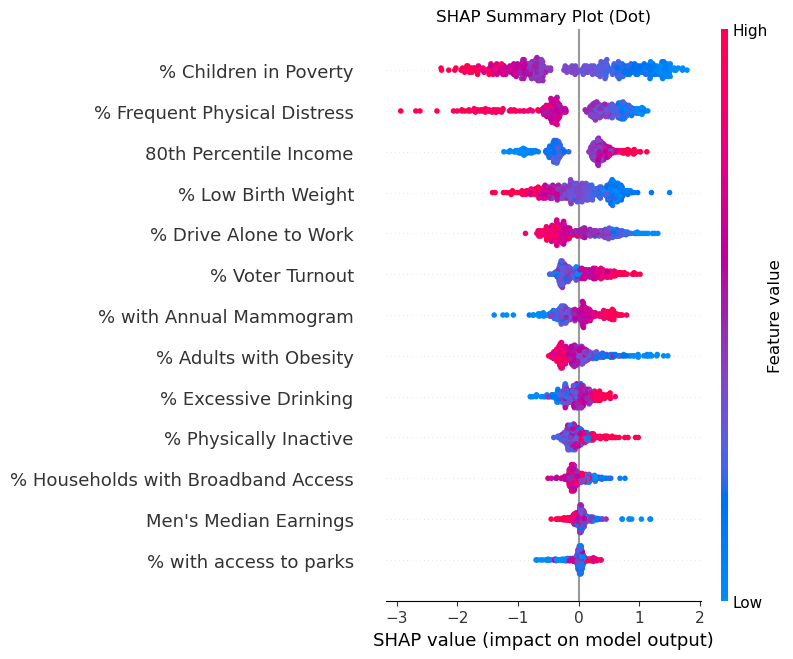

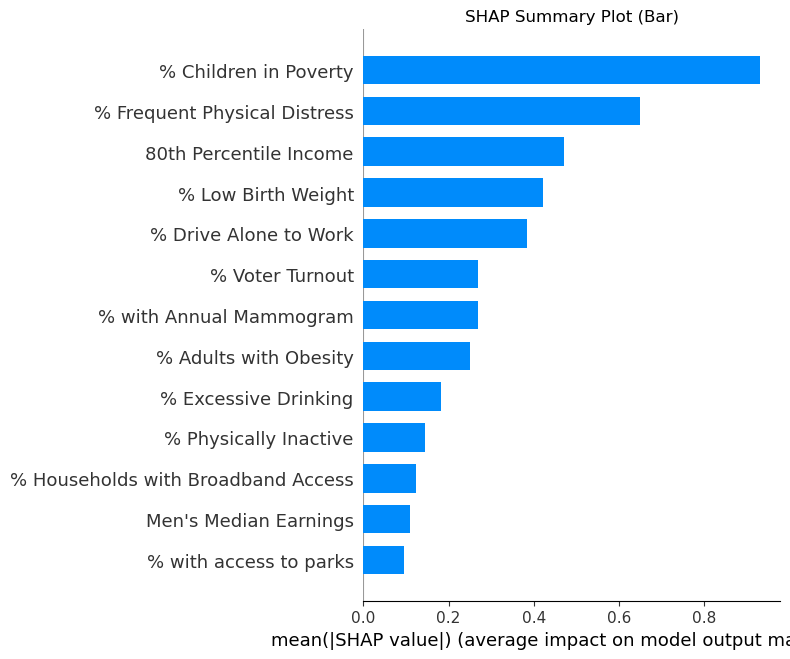

Dependence plot for: % Adults with Obesity


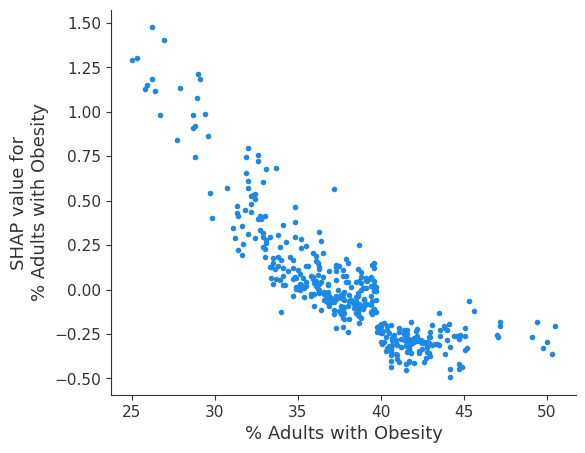

Dependence plot for: 80th Percentile Income


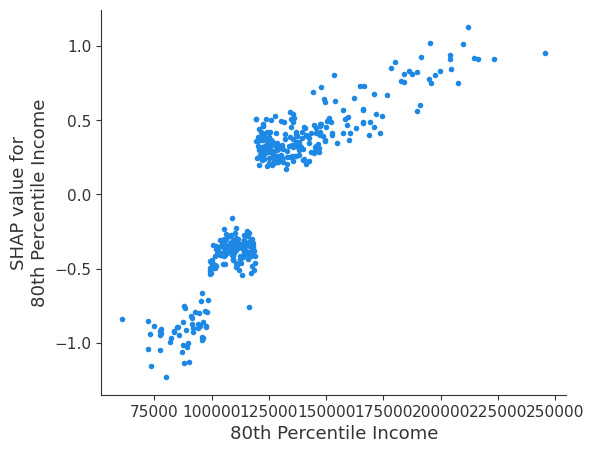

Dependence plot for: % Frequent Physical Distress


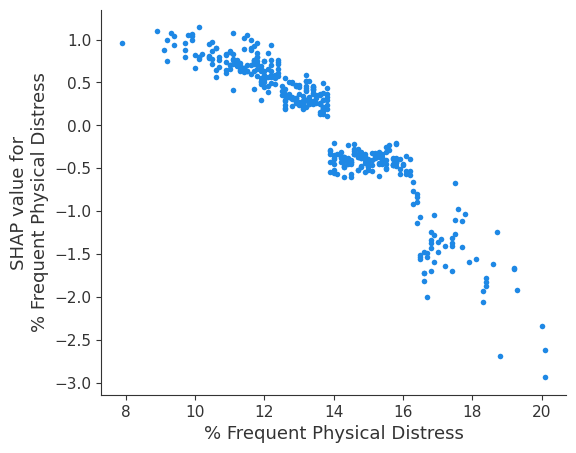

In [8]:
# ======================================
# SHAP EXPLAINABILITY FOR XGBOOST MODEL
# ======================================

import shap
import matplotlib.pyplot as plt

# 1. Create SHAP explainer
explainer = shap.TreeExplainer(best_model)

# 2. Compute SHAP values for test set
shap_values = explainer.shap_values(X_eval)

# 3. SHAP Summary Dot Plot
plt.title("SHAP Summary Plot (Dot)")
shap.summary_plot(shap_values, X_eval, plot_type="dot")
plt.show()

# 4. SHAP Summary Bar Plot
plt.title("SHAP Summary Plot (Bar)")
shap.summary_plot(shap_values, X_eval, plot_type="bar")
plt.show()

# 5. SHAP Dependence Plots (edit features as you like)

top_features = [
    "% Adults with Obesity",
    "80th Percentile Income",
    "% Frequent Physical Distress"
]

for feat in top_features:
    print(f"Dependence plot for: {feat}")
    shap.dependence_plot(
        feat,
        shap_values,
        X_eval,
        interaction_index=None   # SHAP auto-detects best interaction
    )


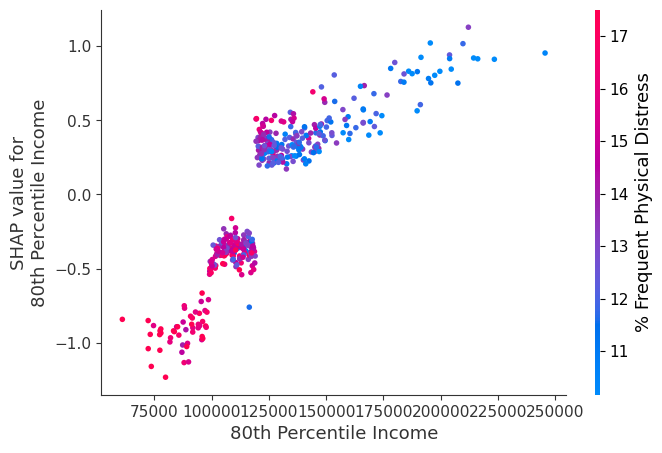

In [9]:
shap.dependence_plot("80th Percentile Income", shap_values, X_eval)
